In [ ]:
import pandas as pd
import numpy as np
from src_RF_DT import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from matplotlib import pyplot as plt

# 1.0 - Classificação de Presença Baseado em Fatores Socioeconômicos Usando Decision Tree

In [2]:
colunas = ['Q001','Q002','Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 
           'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'TP_PRESENCA_LC', 'TP_PRESENCA_CH', 'TP_PRESENCA_CN', 'TP_PRESENCA_MT', 
           'TP_FAIXA_ETARIA', 'TP_ESTADO_CIVIL', 'TP_ESCOLA', 'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 
           'NU_ANO', 'TP_LOCALIZACAO_ESC','TP_SIT_FUNC_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_DEPENDENCIA_ADM_ESC']

df = pd.read_parquet("enem_parquet", columns = colunas)

## 1.1 - Pré-Processamento dos Dados

In [3]:
df = pre_processor_rf_dt(df, modelo='DT', n_samples = 100_000)

## 1.2 - Construção da Matriz X e Vetor y

In [4]:
X = df.drop([ 'FALTOU'], axis=1)

y = df['FALTOU']

In [5]:
X.columns

Index(['Q005', 'TP_FAIXA_ETARIA', 'TP_ESTADO_CIVIL', 'TP_ESCOLA',
       'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 'NU_ANO', 'TP_DEPENDENCIA_ADM_ESC',
       'escolaridade_pai', 'escolaridade_mae', 'escolaridade_pais_max',
       'ocupacao_pai', 'ocupacao_mae', 'renda_familiar', 'score_bens_servicos',
       'score_bens_dom', 'score_equipamentos', 'score_estrutura_casa',
       'acesso_computador', 'acesso_internet'],
      dtype='object')

## 1.3 - Separação em Dados de Treino, Validação e Teste

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

## 1.4 - Treinando o Modelo

In [7]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

print("Ein: %0.4f" % (1 - accuracy_score(y_train, clf.predict(X_train)) ))
print("Eout: %0.4f" % (1 - accuracy_score(y_val, clf.predict(X_val)) ))

print(classification_report(y_val, clf.predict(X_val)))

Ein: 0.0124
Eout: 0.3499
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      3488
           1       0.35      0.36      0.36      1288

    accuracy                           0.65      4776
   macro avg       0.56      0.56      0.56      4776
weighted avg       0.65      0.65      0.65      4776



## 1.5 - Plotando a Árvore

In [8]:
# plt.figure(figsize=(50,20))
# plot_tree(
#     clf,
#     filled=True, 
#     proportion = True,
#     fontsize=12, 
#     rounded = True)
# plt.show()

## 1.6 - Utilizando o algoritmo de Minimal Cost-Complexity

C:\Users\Micael\AppData\Local\Temp\ipykernel_5604\306740880.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


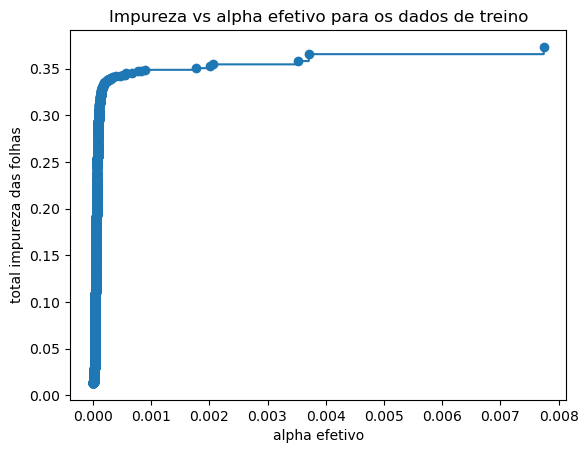

In [9]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("alpha efetivo")
ax.set_ylabel("total impureza das folhas")
ax.set_title("Impureza vs alpha efetivo para os dados de treino")
fig.show()

## 1.7 - Regularizar o alpha com Minimal Cost-Complexity via cross-validation

In [12]:
alphas_reduzidos = np.unique(np.quantile(path.ccp_alphas, np.linspace(0, 1, 200)))

param_grid = {
    'ccp_alpha': alphas_reduzidos,
    'class_weight':['balanced']
}

CV_clf = GridSearchCV(estimator=clf, param_grid=param_grid, cv = 5, verbose=2, n_jobs=-1)

CV_clf.fit(X_train, y_train)


print('Ein: %0.4f' % (1 - accuracy_score(y_train, CV_clf.predict(X_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, CV_clf.predict(X_test))))
print(classification_report(y_test, CV_clf.predict(X_test)))

Fitting 5 folds for each of 166 candidates, totalling 830 fits
Ein: 0.2722
Eout: 0.2749
              precision    recall  f1-score   support

           0       0.78      0.88      0.82      4362
           1       0.48      0.31      0.38      1608

    accuracy                           0.73      5970
   macro avg       0.63      0.59      0.60      5970
weighted avg       0.70      0.73      0.70      5970



In [11]:
# best_tree = CV_clf.best_estimator_

# plt.figure(figsize=(50,20))

# plot_tree(
#     best_tree,
#     filled=True,
#     proportion=True,
#     fontsize=12,
#     rounded=True
# )

# plt.show()